# Import Libraries And Load Datasets

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)
# Models
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

# PyTorch
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


# Pytorch setup for GPU

In [ ]:
print("torch version:", torch.__version__)
print("torch cuda build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
# Check CUDA/GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

# Quick device test
x = torch.randn(2000, 2000, device=device)
y = x @ x
print("MatMul device:", y.device)


torch version: 2.10.0.dev20251030+cu128
torch cuda build: 12.8
CUDA available: True
Using device: cuda
GPU name: NVIDIA GeForce RTX 5070 Laptop GPU
MatMul device: cuda:0


#  1. Data Loading and Initial Cleaning


In [ ]:
DATA_DIR = Path.home() / "Desktop" / "AI PROJECTS" / "adult"
TRAIN_PATH = DATA_DIR / "adult.data"
TEST_PATH  = DATA_DIR / "adult.test"


# Check if the files exist
print("Train:", TRAIN_PATH, "exists:", TRAIN_PATH.exists())
print("Test :", TEST_PATH,  "exists:", TEST_PATH.exists())

# Column names as per UCI Adult dataset documentation
cols = [
    "age","workclass","fnlwgt","education","education_num","marital_status",
    "occupation","relationship","race","sex","capital_gain","capital_loss",
    "hours_per_week","native_country","income"
]

train_df = pd.read_csv(TRAIN_PATH, header=None, names=cols, skipinitialspace=True)
test_df  = pd.read_csv(TEST_PATH, header=None, names=cols, skiprows=1, skipinitialspace=True)
# Function to clean up spaces, fix labels, and handle missing values
def clean_adult(d):
    for c in d.columns:
        if d[c].dtype == "object":
            d[c] = d[c].astype(str).str.strip()
    d = d.replace("?", np.nan)
    d["income"] = d["income"].str.replace(".", "", regex=False).str.strip()
    return d

train_df = clean_adult(train_df)
test_df  = clean_adult(test_df)

df = pd.concat([train_df, test_df], ignore_index=True)
df.shape


Train: C:\Users\jeeva\Desktop\AI PROJECTS\adult\adult.data exists: True
Test : C:\Users\jeeva\Desktop\AI PROJECTS\adult\adult.test exists: True


(48842, 15)

#  EDA ( EVALUATORY DATA ANALYSIS)

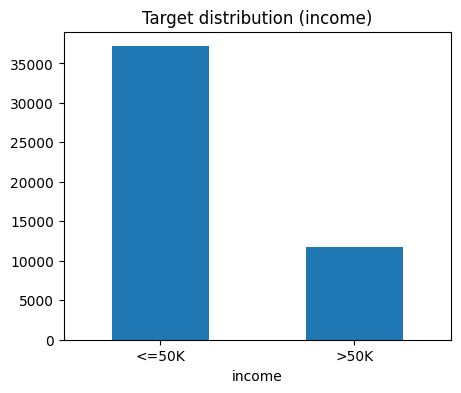

In [6]:
plt.figure(figsize=(5,4))
df["income"].value_counts().plot(kind="bar")
plt.title("Target distribution (income)")
plt.xticks(rotation=0)
plt.show()


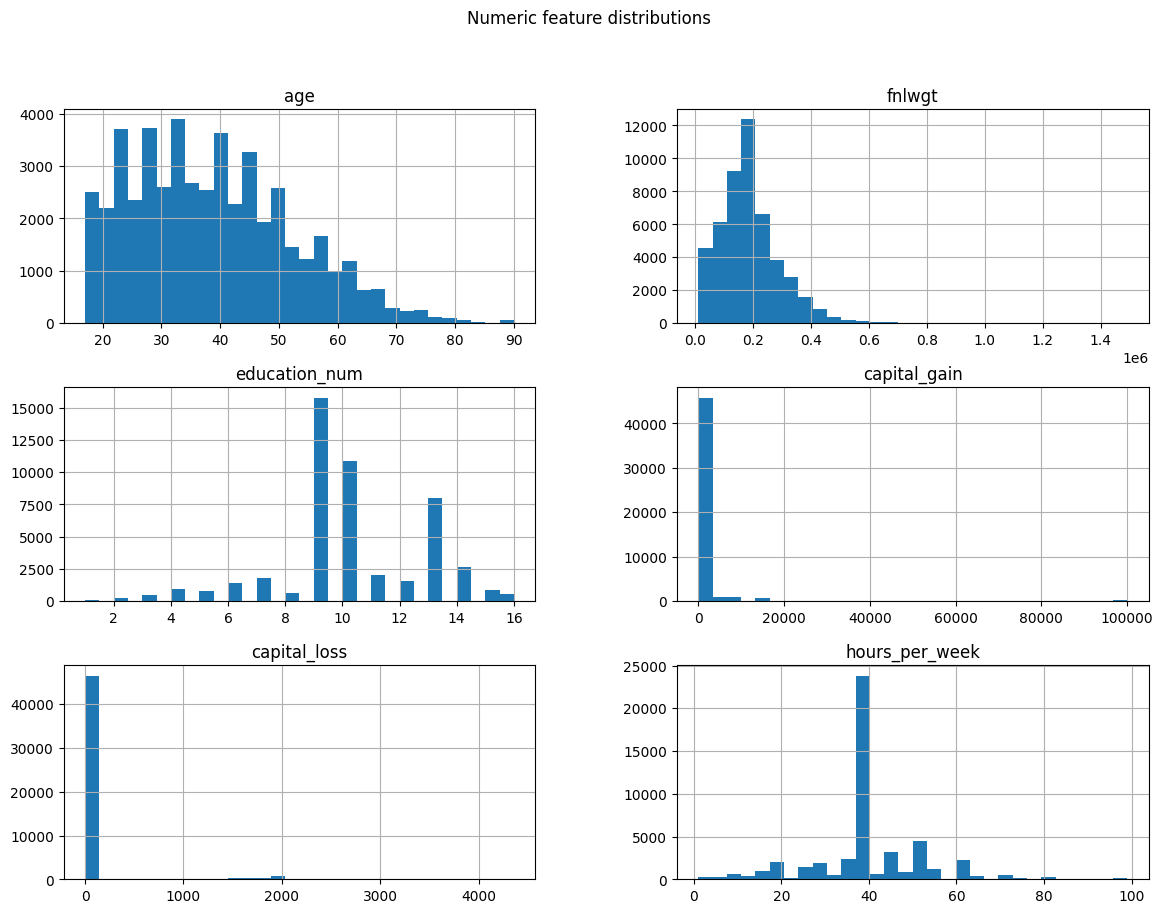

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

df[num_cols].hist(bins=30, figsize=(14,10))
plt.suptitle("Numeric feature distributions")
plt.show()


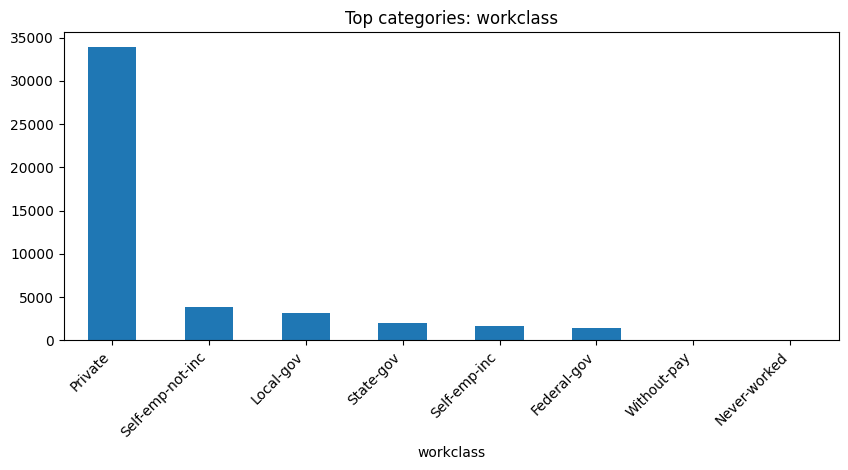

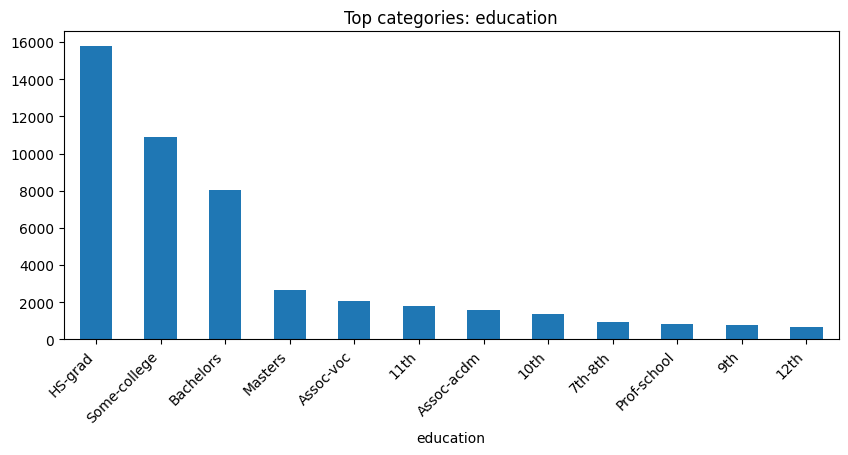

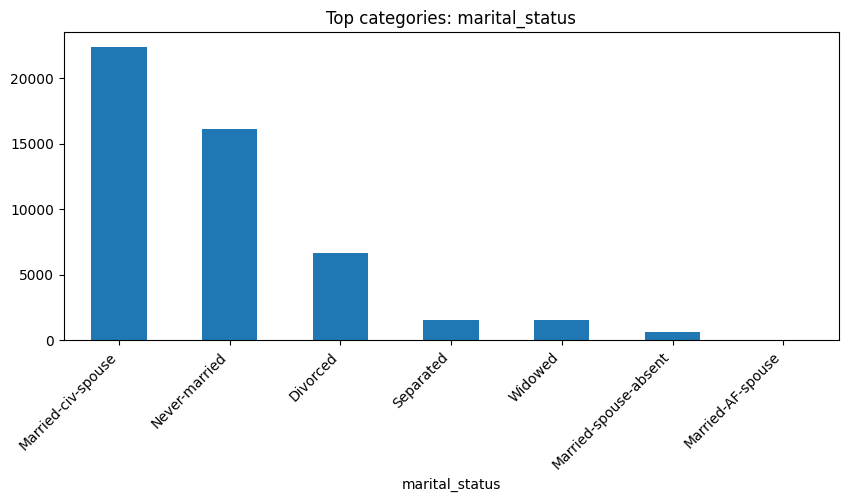

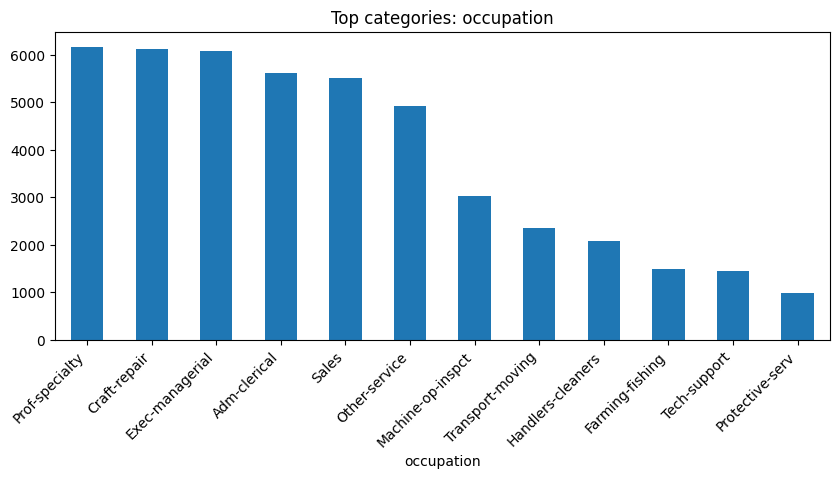

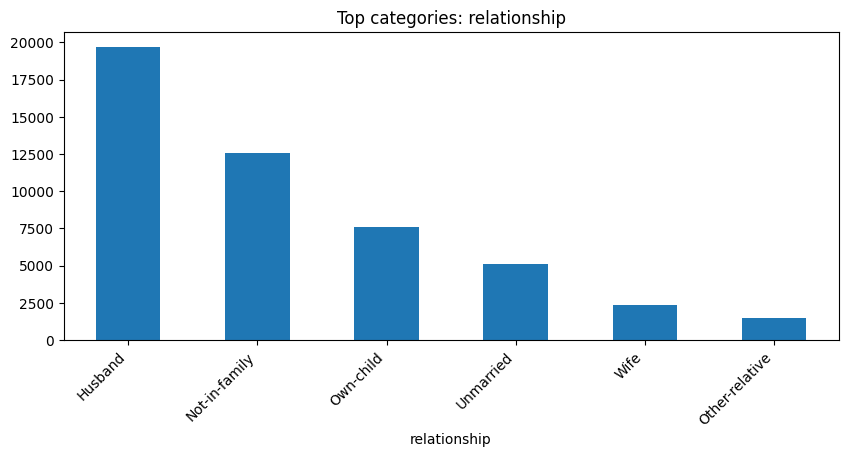

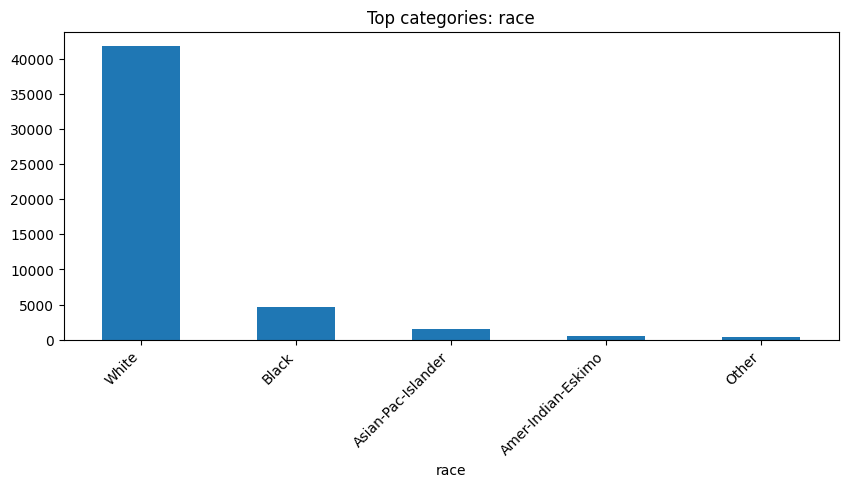

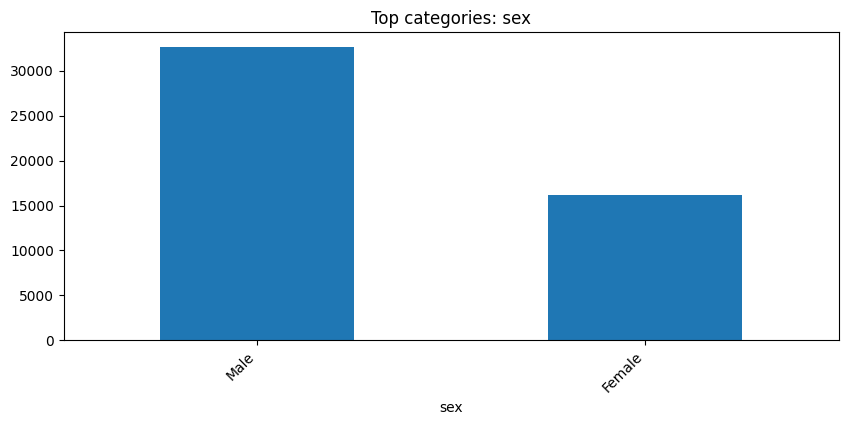

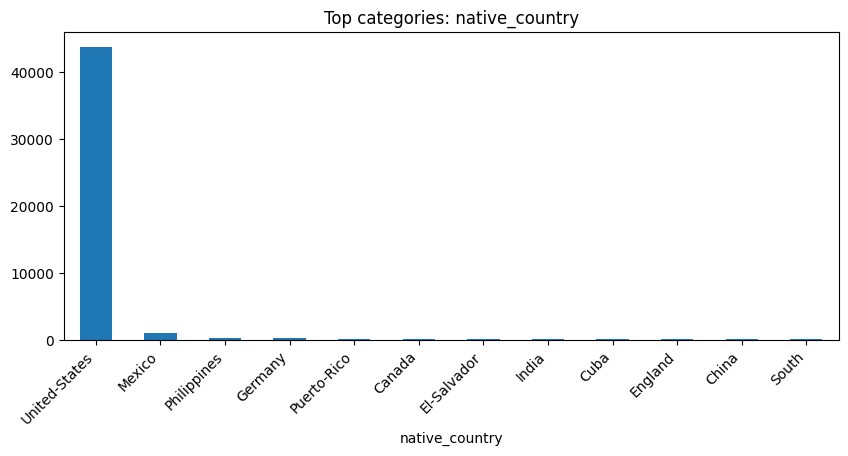

In [8]:
for c in ["workclass","education","marital_status","occupation","relationship","race","sex","native_country"]:
    plt.figure(figsize=(10,4))
    df[c].value_counts().head(12).plot(kind="bar")
    plt.title(f"Top categories: {c}")
    plt.xticks(rotation=45, ha="right")
    plt.show()


# Preprocessing pipeline

In [10]:
X = df.drop(columns=["income"])
y = (df["income"] == ">50K").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = [c for c in X_train.columns if c not in num_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)


# Classical Model Training and Evaluation

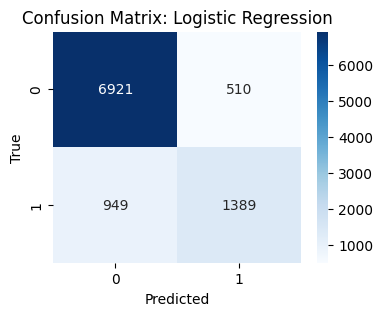

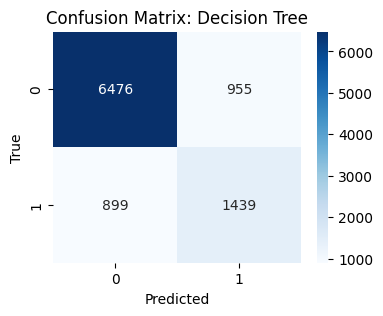

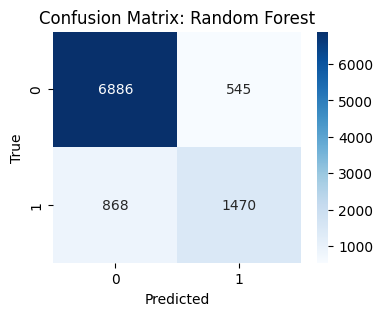

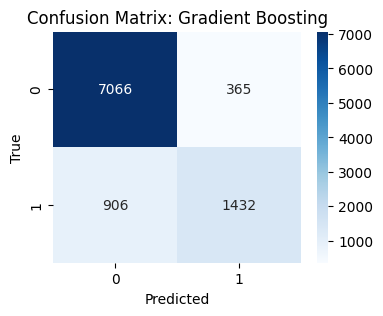

,model,accuracy,precision,recall,f1,roc_auc
3,Gradient Boosting,0.869895,0.796884,0.612489,0.692624,0.923716
2,Random Forest,0.855359,0.729529,0.628743,0.675396,0.905648
0,Logistic Regression,0.850650,0.731438,0.594098,0.655653,0.904222
1,Decision Tree,0.810216,0.601086,0.615483,0.608199,0.743458


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
roc_data = {}
pipes = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", clf)
    ])
    pipe.fit(X_train, y_train)
    pipes[name] = pipe

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    res = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }
    results.append(res)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df


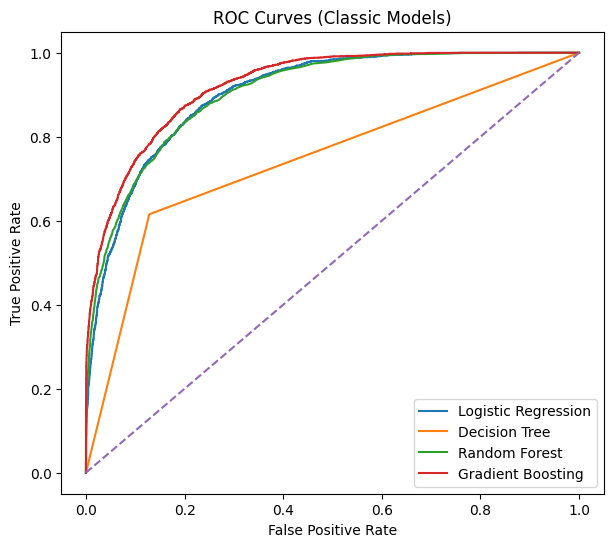

'Gradient Boosting'

In [ ]:
# Compare results

plt.figure(figsize=(7,6))
for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=name)
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Classic Models)")
plt.legend()
plt.show()

best_model_name = results_df.iloc[0]["model"]
best_model_name


# PyTorch Neural Network (ANN)

In [ ]:
#  Convert data to model-ready format
X_train_proc = preprocess.fit_transform(X_train)
X_test_proc  = preprocess.transform(X_test)

# PyTorch wants dense float32 tensors
if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()
    X_test_proc  = X_test_proc.toarray()

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_proc, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Convert to torch tensors
Xtr_t = torch.tensor(X_tr, dtype=torch.float32)
Xva_t = torch.tensor(X_val, dtype=torch.float32)
Xte_t = torch.tensor(X_test_proc, dtype=torch.float32)

ytr_t = torch.tensor(y_tr.values, dtype=torch.float32).view(-1, 1)
yva_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
yte_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=256, shuffle=False)

Xtr_t.shape, ytr_t.shape


(torch.Size([31258, 105]), torch.Size([31258, 1]))

In [14]:
class IncomeANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)  # logits
        )

    def forward(self, x):
        return self.net(x)

model = IncomeANN(X_tr.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model


IncomeANN(
  (net): Sequential(
    (0): Linear(in_features=105, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

# Model taraining with early stopping

In [15]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0

    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            total_loss += loss.item() * xb.size(0)
            correct += (preds == yb).sum().item()
            n += xb.size(0)

    return total_loss / n, correct / n


EPOCHS = 30
patience = 5
best_val_loss = float("inf")
best_state = None
bad_epochs = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("Training on:", device)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)

    train_losses.append(tr_loss); train_accs.append(tr_acc)
    val_losses.append(va_loss);   val_accs.append(va_acc)

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")

    # Early stopping
    if va_loss < best_val_loss - 1e-4:
        best_val_loss = va_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping triggered.")
            break

# Restore best weights
if best_state is not None:
    model.load_state_dict(best_state)


Training on: cuda
Epoch 01 | train loss 0.3867 acc 0.8248 | val loss 0.3123 acc 0.8562
Epoch 02 | train loss 0.3116 acc 0.8544 | val loss 0.3068 acc 0.8604
Epoch 03 | train loss 0.3078 acc 0.8560 | val loss 0.3075 acc 0.8607
Epoch 04 | train loss 0.3058 acc 0.8573 | val loss 0.3071 acc 0.8605
Epoch 05 | train loss 0.3034 acc 0.8590 | val loss 0.3056 acc 0.8603
Epoch 06 | train loss 0.3020 acc 0.8614 | val loss 0.3056 acc 0.8623
Epoch 07 | train loss 0.3000 acc 0.8607 | val loss 0.3100 acc 0.8585
Epoch 08 | train loss 0.2977 acc 0.8613 | val loss 0.3103 acc 0.8569
Epoch 09 | train loss 0.2965 acc 0.8622 | val loss 0.3105 acc 0.8595
Epoch 10 | train loss 0.2948 acc 0.8632 | val loss 0.3140 acc 0.8575
Early stopping triggered.


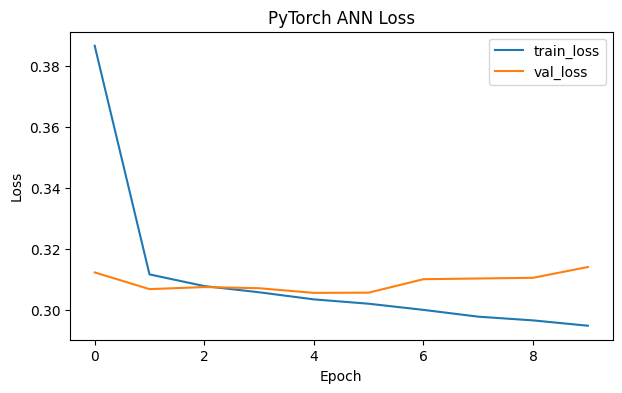

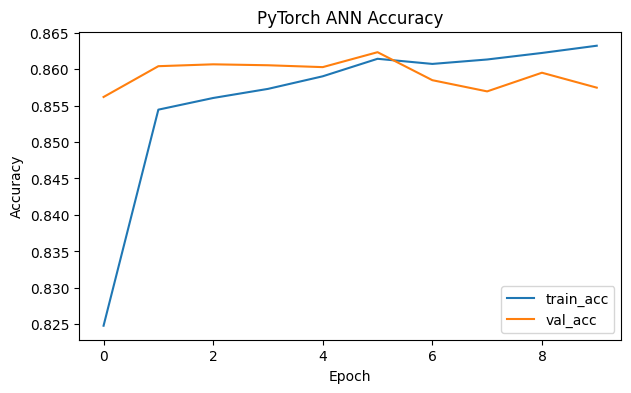

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.title("PyTorch ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
# Plot accuracy
plt.figure(figsize=(7,4))
plt.plot(train_accs, label="train_acc")
plt.plot(val_accs, label="val_acc")
plt.title("PyTorch ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


#  Evaluation & Comparison

In [ ]:
model.eval()
with torch.no_grad():
    logits = model(Xte_t.to(device)).cpu().numpy().ravel()
    ann_proba = 1 / (1 + np.exp(-logits))
# Get predictions
ann_pred = (ann_proba >= 0.5).astype(int)

# Collect ANN metrics
ann_metrics = {
    "model": "ANN (PyTorch)",
    "accuracy": accuracy_score(y_test, ann_pred),
    "precision": precision_score(y_test, ann_pred, zero_division=0),
    "recall": recall_score(y_test, ann_pred, zero_division=0),
    "f1": f1_score(y_test, ann_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, ann_proba)
}
ann_metrics


{'model': 'ANN (PyTorch)',
 'accuracy': 0.8597604667826799,
 'precision': 0.7441977800201817,
 'recall': 0.6308810949529512,
 'f1': 0.6828703703703703,
 'roc_auc': np.float64(0.9124199262815854)}

In [ ]:
best_pipe = pipes[best_model_name]
best_proba = best_pipe.predict_proba(X_test)[:, 1]
# Compare ANN with best classic model
best_row = results_df[results_df["model"] == best_model_name].iloc[0].to_dict()
compare_df = pd.DataFrame([best_row, ann_metrics]).set_index("model")
compare_df


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Gradient Boosting,0.869895,0.796884,0.612489,0.692624,0.923716
ANN (PyTorch),0.859760,0.744198,0.630881,0.682870,0.912420


# Comparison Classic vs ANN Models

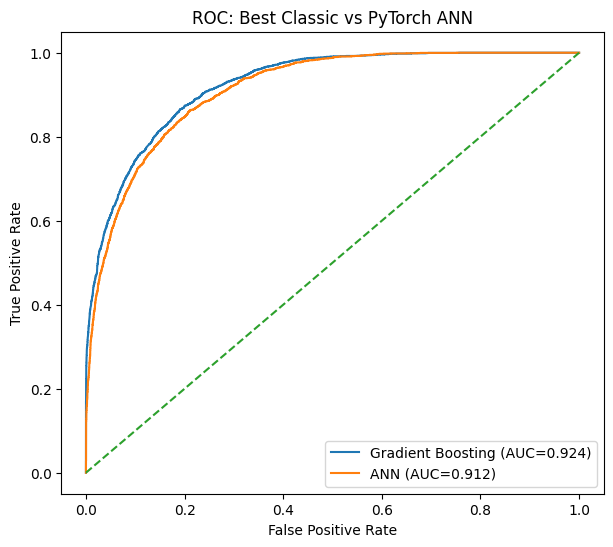

In [ ]:
fpr_b, tpr_b, _ = roc_curve(y_test, best_proba)
fpr_a, tpr_a, _ = roc_curve(y_test, ann_proba)
# Plot ROC curves
plt.figure(figsize=(7,6))
plt.plot(fpr_b, tpr_b, label=f"{best_model_name} (AUC={roc_auc_score(y_test, best_proba):.3f})")
plt.plot(fpr_a, tpr_a, label=f"ANN (AUC={roc_auc_score(y_test, ann_proba):.3f})")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: Best Classic vs PyTorch ANN")
plt.legend()
plt.show()


# Feature Importance and Clustering

In [ ]:
perm = permutation_importance(
    best_pipe, X_test, y_test,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc",
    n_jobs=1   
)

imp_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

imp_df


,feature,importance_mean,importance_std
5,marital_status,0.100278,0.001787
10,capital_gain,0.052950,0.001481
4,education_num,0.035904,0.001805
0,age,0.027456,0.001082
11,capital_loss,0.012348,0.000866
12,hours_per_week,0.011800,0.000272
6,occupation,0.007840,0.000460
7,relationship,0.002654,0.000217
1,workclass,0.001223,0.000127
9,sex,0.000619,0.000191


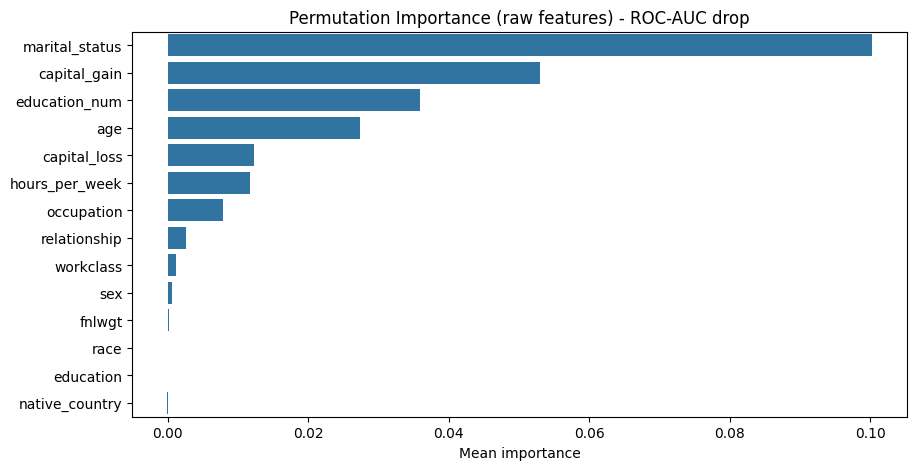

In [ ]:

# Plot feature importance
plt.figure(figsize=(10,5))
sns.barplot(data=imp_df, x="importance_mean", y="feature")
plt.title("Permutation Importance (raw features) - ROC-AUC drop")
plt.xlabel("Mean importance")
plt.ylabel("")
plt.show()


In [ ]:
X_all_proc = preprocess.fit_transform(X)
if hasattr(X_all_proc, "toarray"):
    X_all_proc = X_all_proc.toarray()
# Dimensionality reduction + clustering
pca = PCA(n_components=2, random_state=42)
X_pca2 = pca.fit_transform(X_all_proc)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca2)

sil = silhouette_score(X_pca2, clusters)
ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

print("Silhouette:", sil)
print("ARI:", ari)
print("NMI:", nmi)


Silhouette: 0.35649030306193946
ARI: 0.07288223379974519
NMI: 0.14593019620223757


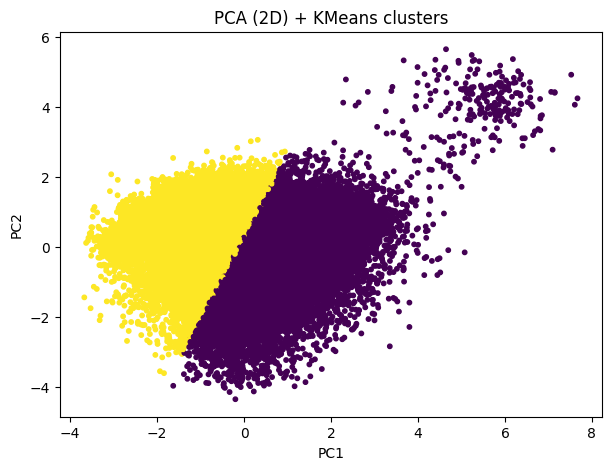

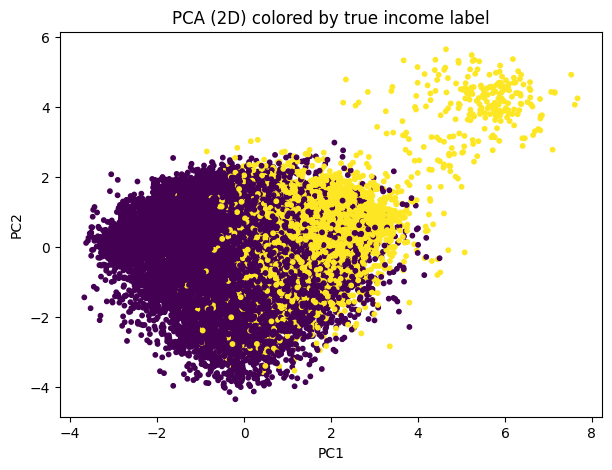

In [23]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=clusters, s=10)
plt.title("PCA (2D) + KMeans clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=y, s=10)
plt.title("PCA (2D) colored by true income label")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


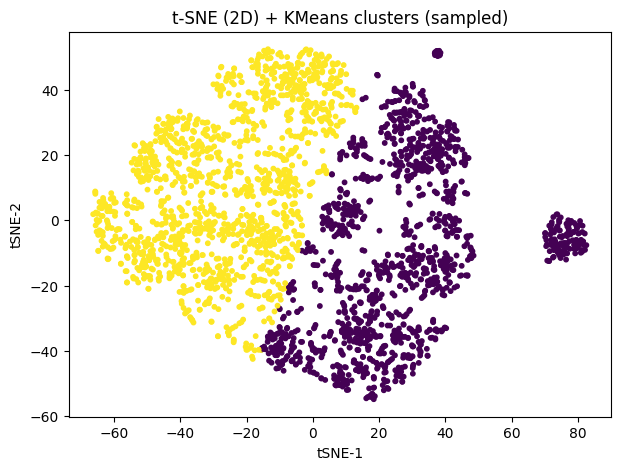

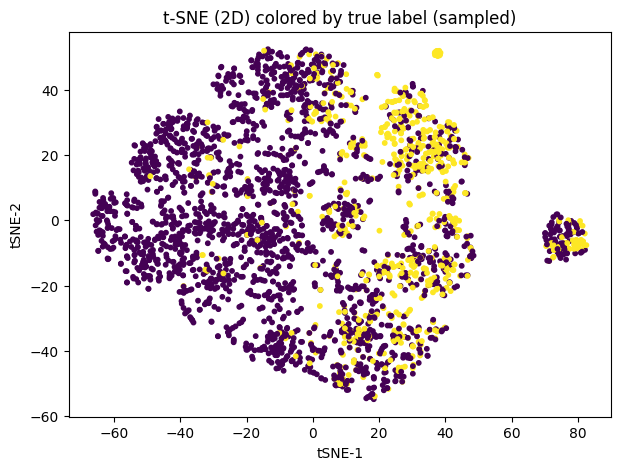

In [24]:
from sklearn.manifold import TSNE

n_sample = min(3000, X_all_proc.shape[0])
idx = np.random.RandomState(42).choice(X_all_proc.shape[0], size=n_sample, replace=False)

X_sample = X_all_proc[idx]
y_sample = y.iloc[idx].values

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X_sample)

km_tsne = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_tsne)

plt.figure(figsize=(7,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=km_tsne, s=10)
plt.title("t-SNE (2D) + KMeans clusters (sampled)")
plt.xlabel("tSNE-1")
plt.ylabel("tSNE-2")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_sample, s=10)
plt.title("t-SNE (2D) colored by true label (sampled)")
plt.xlabel("tSNE-1")
plt.ylabel("tSNE-2")
plt.show()


# summary

This projec uses UCI adult income dataset to predict weather someone earns more than 50 k per year which compare traditional models with simple neural network built in PyTorch

First the code loads the training and test files and cleans up missing or messy values and fixes labels that are consistant. The dataset is dividede into training test set using stratified sampling. The pipeline mainly handels the missing values , scales and neumeric columns. The notebook then trains several classic models such as Logistic Regression, Decision Tree, Random Forest and Gradient Boosting and evaluates them on accuracy, precision, recall, F1‑score and ROC‑AUC. ROC curves and confusion matrices help visualize how each model performs.

Gradient Boosing is the best model overall with the highest ROC-AUC 0.92 and F1 score whereas the PyTorch ANN performs quite similarly and definitely surpasses the Decision Tree and Logistic Regression.
The visualizations reinforced these findings. The ROC curves showed Gradient Boosting sitting above the other lines almost everywhere which indicates very good performance across a wide range of thresholds. 

The PyTorch ANN is less interpretable than tree-based models and required careful tuning to avoid overfitting.Limitations include class imbalences where individuals earning more than $50k represent a smaller fraction of the dataThe clustering and dimentionality reduction plots show overlapping regions of 2 income classes that suggest that the features are not perfectly seperated in between high and low income groups 


